# Monarch grid inference

Predicts monarch (`Danaus plexippus`) habitat suitability at every land grid cell on **2025-08-15** and **2025-11-15** using the eButterfly-trained STEM-LM checkpoint with all species masked (`p=1.0`). Source pool is the full set of eButterfly observations.


In [20]:
# Optional Colab setup: uncomment when running on Colab.
# from google.colab import drive
# drive.mount("/content/drive")
# !git clone https://github.com/JackyKaiyuanL/STEM-LM.git /content/STEM-LM
# %cd /content/STEM-LM
# !pip install -q transformers scikit-learn h3 cartopy
# !apt-get -qq install -y fonts-liberation

import os, sys
# REPO_ROOT = root of the STEM-LM repo (so we can import STEMLM_*).
REPO_ROOT = os.environ.get(
    "REPO_ROOT",
    os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
    if "__file__" in dir() else os.getcwd(),
)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
/content/STEM-LM


In [21]:
import json, inspect, time
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader, Subset

from STEMLM_data  import JSDMDataset, FixedPValCollator, compute_dist_info
from STEMLM_model import JSDMConfig, JSDMForMaskedSpeciesPrediction
from STEMLM_metric import run_forward

# All grid CSVs, eButterfly CSV, splits JSON, and model dirs live in WORK_DIR.
WORK_DIR  = os.environ.get('WORK_DIR', os.getcwd())  # set to dir containing grid CSVs, model dir, train CSV, splits
FULL_DIR  = f'{WORK_DIR}/out_ebutterfly_ablation_seed41_full'

TRAIN_CSV   = f'{WORK_DIR}/ebutterfly_na_2011_2025.csv'
SPLITS_FILE = f'{WORK_DIR}/ebutterfly_splits.json'
DATES = ['2025-05-15', '2025-07-15', '2025-09-15', '2025-11-15']
GRID_CSVS = {d: f'{WORK_DIR}/monarch_grid_{d}.csv' for d in DATES}
MONARCH_SPECIES = 'Danaus plexippus'
BAG_K = 10
BATCH_SIZE = 512

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')


device: cuda


## Load full model

In [22]:
cfg_params = set(inspect.signature(JSDMConfig).parameters)

def load_model(model_dir):
    with open(f'{model_dir}/config.json') as f:
        cfg_dict = json.load(f)
    cfg = JSDMConfig(**{k: v for k, v in cfg_dict.items() if k in cfg_params})
    m = JSDMForMaskedSpeciesPrediction(cfg)
    sd = torch.load(f'{model_dir}/best_model.pt', map_location=device, weights_only=False)
    if isinstance(sd, dict) and 'model_state_dict' in sd:
        sd = sd['model_state_dict']
    m.load_state_dict(sd)
    return m.to(device).eval(), cfg

model_full, config = load_model(FULL_DIR)
print(f'full model loaded: {sum(p.numel() for p in model_full.parameters()):,} params, S={config.num_species}')

full model loaded: 3,935,466 params, S=173


## Build combined dataset

Concatenate the eButterfly CSV (rows 0..N_obs−1, used as source pool) with the grid CSV (rows N_obs..N_obs+N_grid−1, the targets). Grid cells get all-zero species columns; with `p=1.0` masking those values are irrelevant.

In [23]:
obs_df = pd.read_csv(TRAIN_CSV)
species_cols = [c for c in obs_df.columns
                if c not in ['time', 'latitude', 'longitude']
                and not c.startswith('env_')]
assert MONARCH_SPECIES in species_cols, f'{MONARCH_SPECIES} not in dataset'
print(f'eButterfly: {len(obs_df):,} rows, {len(species_cols)} species')

n_obs = len(obs_df)
all_obs_idx = np.arange(n_obs)
print(f'source pool: all {n_obs:,} obs (train+val+test); grid cells excluded from source.')

eButterfly: 17,077 rows, 173 species
source pool: all 17,077 obs (train+val+test); grid cells excluded from source.


In [24]:
def build_combined_dataset(grid_csv):
    grid = pd.read_csv(grid_csv)
    zeros = pd.DataFrame(0, index=grid.index, columns=species_cols, dtype=np.int8)
    grid = pd.concat([grid, zeros], axis=1)
    grid = grid[obs_df.columns]
    combined = pd.concat([obs_df, grid], ignore_index=True)
    tmp_csv = '/tmp/_combined_grid.csv'
    combined.to_csv(tmp_csv, index=False)
    dataset = JSDMDataset(
        csv_path=tmp_csv,
        num_source_sites=config.num_source_sites,
        no_time=False,
        euclidean_coords=False,
    )
    return dataset, len(grid), grid

## Inference function

K=10 source-pool resamples per cell, all species masked (p=1.0).

In [25]:
@torch.no_grad()
def predict_monarch_on_grid(model, grid_csv, T_star=1.0, base_seed=42):
    """If T_star != 1.0, applies Guo et al. 2017 temperature scaling to logits
    before sigmoid: p = sigmoid(logit / T_star). Set T_star=1.0 for raw output."""
    dataset, n_grid, grid = build_combined_dataset(grid_csv)
    dist_info = compute_dist_info(dataset)
    monarch_idx = dataset.species_cols.index(MONARCH_SPECIES)

    dataset.source_pool = all_obs_idx
    grid_eval_idx = np.arange(n_obs, n_obs + n_grid)
    print(f'  source pool: {len(dataset.source_pool):,} obs | grid targets: {n_grid:,} | T*={T_star:.4f}')

    dist_info_dev = {k: (v.to(device) if torch.is_tensor(v) else v)
                     for k, v in dist_info.items()}

    sum_p = np.zeros(n_grid, dtype=np.float64)
    target_order = None

    for k in range(BAG_K):
        np.random.seed(base_seed + 7919 * k)
        torch.manual_seed(base_seed + 7919 * k)

        collator = FixedPValCollator(
            p=1.0,
            site_lats=dist_info['site_lats'],
            site_lons=dist_info['site_lons'],
            site_times=dist_info['site_times'],
            spatial_scale_km=dist_info['spatial_scale_km'],
            euclidean=dist_info.get('euclidean', False),
            base_seed=base_seed + 7919 * k,
        )
        loader = DataLoader(
            Subset(dataset, grid_eval_idx),
            batch_size=BATCH_SIZE, shuffle=False,
            collate_fn=collator,
            num_workers=8, persistent_workers=True, pin_memory=True,
        )

        offset = 0
        order_this_pass = []
        for batch in loader:
            out = run_forward(model, batch, dist_info_dev, device)
            logits = out.logits.squeeze(-1).float() / T_star
            probs = torch.sigmoid(logits).cpu().numpy()
            B = probs.shape[0]
            sum_p[offset:offset + B] += probs[:, monarch_idx].astype(np.float64)
            order_this_pass.extend(
                batch['target_site_idx'].squeeze(-1).cpu().numpy().tolist())
            offset += B
        if target_order is None:
            target_order = order_this_pass
        print(f'  pass {k+1}/{BAG_K} done')

    avg_suitability = sum_p / BAG_K
    target_idx_arr = np.array(target_order)
    grid_local = target_idx_arr - n_obs
    return pd.DataFrame({
        'latitude':    grid.latitude.values[grid_local],
        'longitude':   grid.longitude.values[grid_local],
        'suitability': avg_suitability,
    })


## Temperature scaling (Guo et al. 2017)

Fit a single scalar $T^\star$ on the validation split by L-BFGS minimization of binary cross-entropy. Applied uniformly at inference as $p = \sigma(z/T^\star)$.

In [26]:
import torch.nn.functional as F

with open(SPLITS_FILE) as f:
    splits = json.load(f)

def gather_logits_labels(model, split_idx):
    """Run model on the given H3-blocked split with p=1.0 masking; return
    (logits, labels) only at masked positions (label != -100). Used for
    temperature fitting (val) and post-T evaluation (test) per Guo 2017."""
    ds = JSDMDataset(csv_path=TRAIN_CSV,
                     num_source_sites=config.num_source_sites,
                     no_time=False, euclidean_coords=False)
    dist_info = compute_dist_info(ds)
    ds.source_pool = np.array(splits['train'])

    dist_info_dev = {k: (v.to(device) if torch.is_tensor(v) else v)
                     for k, v in dist_info.items()}

    collator = FixedPValCollator(
        p=1.0,
        site_lats=dist_info['site_lats'], site_lons=dist_info['site_lons'],
        site_times=dist_info['site_times'],
        spatial_scale_km=dist_info['spatial_scale_km'],
        euclidean=dist_info.get('euclidean', False),
        base_seed=42)
    loader = DataLoader(Subset(ds, split_idx),
                        batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collator,
                        num_workers=8, persistent_workers=True, pin_memory=True)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            out = run_forward(model, batch, dist_info_dev, device)
            all_logits.append(out.logits.squeeze(-1).float().cpu())
            all_labels.append(batch['labels'].squeeze(-1).cpu())
    return torch.cat(all_logits, 0), torch.cat(all_labels, 0)


def fit_temperature(val_logits, val_labels):
    """Guo et al. 2017 §4.2: minimize NLL with L-BFGS over a single scalar."""
    mask = (val_labels != -100)
    z = val_logits[mask].float()
    y = val_labels[mask].float()
    log_T = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_T], lr=0.1, max_iter=200,
                            line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(z / log_T.exp(), y)
        loss.backward()
        return loss
    opt.step(closure)
    return float(log_T.exp().item())


def ece_binary(logits, labels, T=1.0, n_bins=15):
    mask = (labels != -100)
    z = logits[mask].float()
    y = labels[mask].float()
    p = torch.sigmoid(z / T)
    edges = torch.linspace(0, 1, n_bins + 1)
    err = 0.0
    for b in range(n_bins):
        m = (p >= edges[b]) & (p < edges[b+1])
        if m.any():
            err += (m.float().mean() *
                    (y[m].mean() - p[m].mean()).abs()).item()
    return err


val_idx  = np.array(splits['val'])
test_idx = np.array(splits['test'])

print('Collecting val + test logits for full model ...')
vl_full, vy_full = gather_logits_labels(model_full, val_idx)
tl_full, ty_full = gather_logits_labels(model_full, test_idx)

T_full = fit_temperature(vl_full, vy_full)
print(f'\n--- Full model temperature scaling (Guo et al. 2017) ---')
print(f'  T*_full                = {T_full:.4f}')
print(f'  val  ECE pre-T  (fit set)        = {ece_binary(vl_full, vy_full):.4f}')
print(f'  val  ECE post-T (fit set)        = {ece_binary(vl_full, vy_full, T=T_full):.4f}')
print(f'  test ECE pre-T  (held-out check) = {ece_binary(tl_full, ty_full):.4f}')
print(f'  test ECE post-T (held-out check) = {ece_binary(tl_full, ty_full, T=T_full):.4f}')


Dataset: 17077 observations, 173 species, 15 env vars
  Computing max pairwise distance (tiled, device=cuda)...
Done.
Dataset: 17077 observations, 173 species, 15 env vars
  Computing max pairwise distance (tiled, device=cuda)...
Done.

--- Full model temperature scaling (Guo et al. 2017) ---
  T*_full                = 0.5652
  val  ECE pre-T  (fit set)        = 0.0651
  val  ECE post-T (fit set)        = 0.0020
  test ECE pre-T  (held-out check) = 0.0553
  test ECE post-T (held-out check) = 0.0060

--- CBI on test (full model) ---
  test mean CBI pre-T  : 0.8105  (n_species=151)
  test mean CBI post-T : 0.7085  (n_species=152)
  ΔCBI = -0.1020


## Full model — all dates

In [27]:
def output_is_current(out_path, grid_csv):
    """Skip only if the output exists AND its row count matches the grid CSV
    (so a stale output from a previous grid version triggers re-inference)."""
    if not os.path.exists(out_path):
        return False
    try:
        return sum(1 for _ in open(out_path)) == sum(1 for _ in open(grid_csv))
    except Exception:
        return False

for date, grid_csv in GRID_CSVS.items():
    out_path = f'{WORK_DIR}/monarch_pred_{date}.csv'
    if output_is_current(out_path, grid_csv):
        print(f'\n=== full  {date} ===  skipping, {out_path} matches grid')
        continue
    print(f'\n=== full  {date} ===')
    t0 = time.time()
    pred = predict_monarch_on_grid(model_full, grid_csv, T_star=T_full)
    pred.to_csv(out_path, index=False)
    print(f'  saved {len(pred):,} rows -> {out_path}  ({time.time()-t0:.1f}s)')
    print(f'  suitability  min={pred.suitability.min():.4f}  '
          f'mean={pred.suitability.mean():.4f}  max={pred.suitability.max():.4f}')



=== full  2025-08-15 ===
Dataset: 28226 observations, 173 species, 15 env vars
  Computing max pairwise distance (tiled, device=cuda)...
Done.
  source pool: 17,077 obs | grid targets: 11,149 | T*=0.5652
  pass 1/10 done
  pass 2/10 done
  pass 3/10 done
  pass 4/10 done
  pass 5/10 done
  pass 6/10 done
  pass 7/10 done
  pass 8/10 done
  pass 9/10 done
  pass 10/10 done
  saved 11,149 rows -> /content/drive/MyDrive/Monarch/monarch_pred_2025-08-15.csv  (91.9s)
  suitability  min=0.0141  mean=0.1944  max=0.5115

=== full  2025-09-15 ===
Dataset: 28226 observations, 173 species, 15 env vars
  Computing max pairwise distance (tiled, device=cuda)...
Done.
  source pool: 17,077 obs | grid targets: 11,149 | T*=0.5652
  pass 1/10 done
  pass 2/10 done
  pass 3/10 done
  pass 4/10 done
  pass 5/10 done
  pass 6/10 done
  pass 7/10 done
  pass 8/10 done
  pass 9/10 done
  pass 10/10 done
  saved 11,149 rows -> /content/drive/MyDrive/Monarch/monarch_pred_2025-09-15.csv  (92.3s)
  suitability  

## Visualization — full model (4-panel migration progression)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


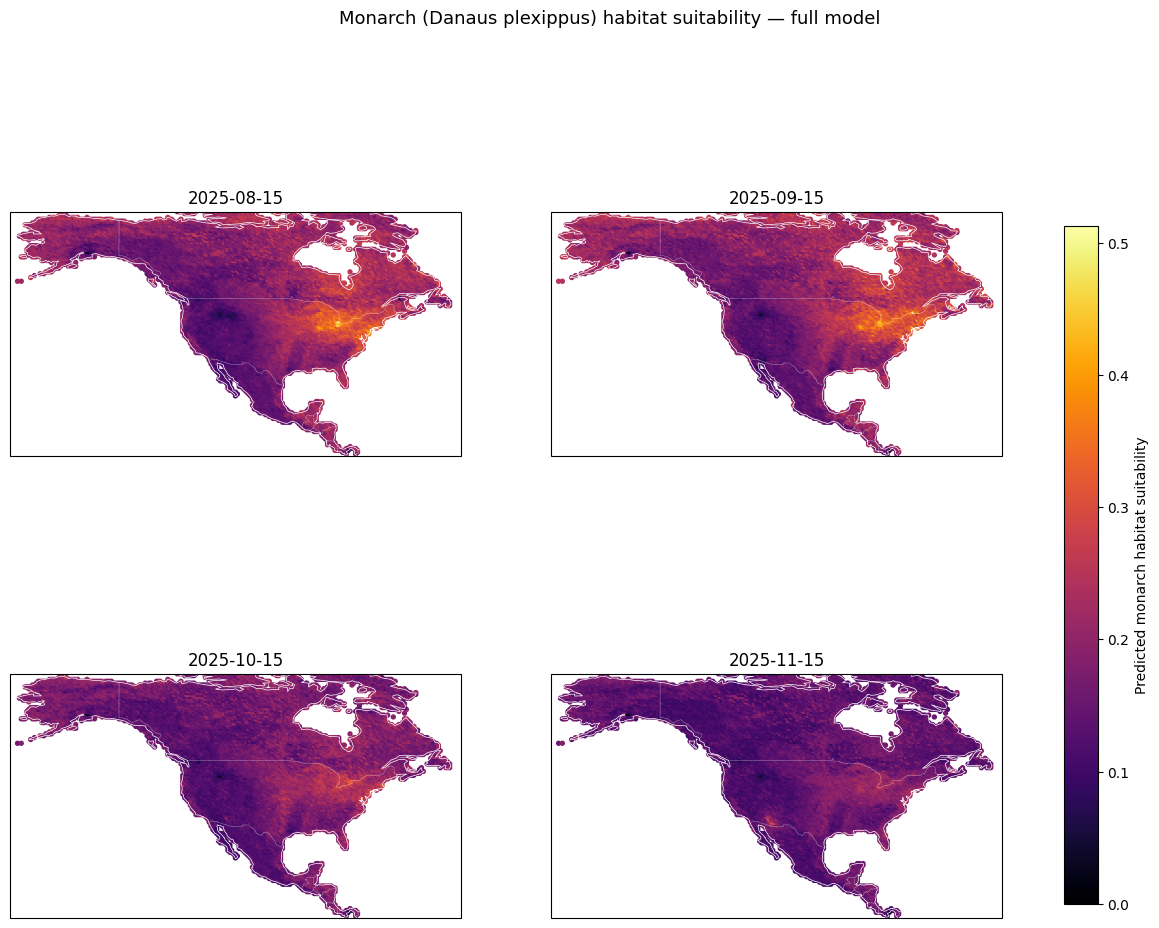

In [29]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib.collections import PolyCollection
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.ops import unary_union
from shapely.geometry import Point
from scipy.spatial import cKDTree

_lib_font = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
if os.path.exists(_lib_font):
    mpl.font_manager.fontManager.addfont(_lib_font)
    plt.rcParams['font.family'] = 'Liberation Sans'

INCLUDE = {"United States of America","Canada","Mexico","Guatemala","Belize",
           "Honduras","El Salvador","Nicaragua","Costa Rica","Panama"}
_countries_shp = shpreader.natural_earth(resolution='50m', category='cultural',
                                          name='admin_0_countries')
_geoms = [r.geometry for r in shpreader.Reader(_countries_shp).records()
          if any(inc.lower() in (r.attributes.get('NAME_LONG','') or r.attributes.get('NAME','')).lower()
                 or (r.attributes.get('NAME_LONG','') or r.attributes.get('NAME','')).lower() in inc.lower()
                 for inc in INCLUDE)]
land_union = unary_union(_geoms)

GREAT = {'Lake Superior','Lake Michigan','Lake Huron','Lake Erie','Lake Ontario'}
_lakes_shp = shpreader.natural_earth(resolution='50m', category='physical', name='lakes')
great_geoms = [r.geometry for r in shpreader.Reader(_lakes_shp).records()
               if (r.attributes.get('name') or '') in GREAT]
gl_union = unary_union(great_geoms)

RES = 0.5
_lons = np.arange(-170.0, -50.0 + RES, RES)
_lats = np.arange(7.0, 72.0 + RES, RES)
_LG, _LT = np.meshgrid(_lons, _lats)
_LG, _LT = _LG.ravel(), _LT.ravel()
_in_land = np.array([land_union.contains(Point(x, y)) for x, y in zip(_LG, _LT)])
_mask = _in_land & ~((_LT >= 18) & (_LT <= 23) & (_LG >= -161) & (_LG <= -154))
_sub_lon, _sub_lat = _LG[_mask], _LT[_mask]
_in_gl = np.array([gl_union.contains(Point(x, y)) for x, y in zip(_sub_lon, _sub_lat)])
full_lon, full_lat = _sub_lon[~_in_gl], _sub_lat[~_in_gl]
print(f'render grid: {len(full_lon):,} cells (land minus Great Lakes)')

cmap = plt.get_cmap('inferno').copy()
cmap.set_bad('white', alpha=0)
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=40,
                              standard_parallels=(20, 60))
extent = [-128, -65, 14, 60]
HEX_R = RES * 0.72
HEX_ANGLES = np.deg2rad(np.array([0, 60, 120, 180, 240, 300]))

def hex_verts(lon, lat, r=HEX_R):
    return np.column_stack([lon + r*np.cos(HEX_ANGLES),
                             lat + r*np.sin(HEX_ANGLES)])

def fill(df):
    tree = cKDTree(df[['longitude','latitude']].values)
    _, idx = tree.query(np.column_stack([full_lon, full_lat]))
    return pd.DataFrame({'longitude': full_lon, 'latitude': full_lat,
                         'suitability': df['suitability'].values[idx]})

def plot_4panel(in_template, out_filename):
    dfs = {d: fill(pd.read_csv(f'{WORK_DIR}/{in_template.format(d=d)}')) for d in DATES}
    vmax = max(d_.suitability.max() for d_ in dfs.values())
    norm = Normalize(vmin=0.0, vmax=vmax)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                             subplot_kw={'projection': proj},
                             gridspec_kw={'wspace': 0.02, 'hspace': 0.02})
    for ax, d in zip(axes.ravel(), DATES):
        df = dfs[d]
        verts = [hex_verts(lo, la) for lo, la in zip(df.longitude, df.latitude)]
        pc = PolyCollection(verts, array=df.suitability.values,
                            cmap=cmap, norm=norm, edgecolor='none',
                            transform=ccrs.PlateCarree())
        ax.add_collection(pc)
        ax.add_geometries(great_geoms, crs=ccrs.PlateCarree(),
                          facecolor='white', edgecolor='none', zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='white', zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor='white', alpha=0.6, zorder=3)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
        ax.text(0.02, 0.96, d, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', color='white',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    fig.colorbar(pc, ax=axes.ravel().tolist(), shrink=0.7, aspect=30,
                 label='Predicted habitat suitability', pad=0.01)
    plt.savefig(f'{WORK_DIR}/{out_filename}', dpi=180, bbox_inches='tight')
    plt.show()

plot_4panel('monarch_pred_{d}.csv', 'monarch_pred_full.png')


## Full model — raw (no temperature scaling)

In [ ]:
for date, grid_csv in GRID_CSVS.items():
    out_path = f'{WORK_DIR}/monarch_pred_raw_{date}.csv'
    if output_is_current(out_path, grid_csv):
        print(f'\n=== full raw  {date} ===  skipping, {out_path} matches grid')
        continue
    print(f'\n=== full raw  {date} ===')
    t0 = time.time()
    pred = predict_monarch_on_grid(model_full, grid_csv, T_star=1.0)
    pred.to_csv(out_path, index=False)
    print(f'  saved {len(pred):,} rows -> {out_path}  ({time.time()-t0:.1f}s)')
    print(f'  suitability  min={pred.suitability.min():.4f}  '
          f'mean={pred.suitability.mean():.4f}  max={pred.suitability.max():.4f}')


## Visualization — full model, raw outputs

In [ ]:
plot_4panel('monarch_pred_raw_{d}.csv', 'monarch_pred_full_raw.png')
